In [1]:
%pip cache purge

%pip install -r ../requirements.txt


Files removed: 0 (0 bytes)
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [9]:
import os
import shutil

DIRECTORIES = [
    "../models", 
    "../data/raw/files"
]
deleted_files = []

for directory in DIRECTORIES:
    if not os.path.exists(directory):
        print(f"Directory '{directory}' does not exist.")
        continue

    for item in os.listdir(directory):
        item_path = os.path.join(directory, item)

        if item == ".gitkeep":
            continue  # Skip .gitkeep

        if os.path.isfile(item_path):
            os.remove(item_path)
            deleted_files.append(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)
            deleted_files.append(item_path + "/")  

if deleted_files:
    print("Deleted files and directories:")
    for file in deleted_files:
        print(f" - {file}")
else:
    print("No files to delete.")


Deleted files and directories:
 - ../models/pipeline_comparison.png
 - ../models/eeg_dataset_20250315_110512/
 - ../models/eeg_model_motor_execution_left_right_20250315_111627_info.json
 - ../models/eeg_model_motor_execution_left_right_20250315_111627.joblib
 - ../models/confusion_matrices.png
 - ../models/subject_performances.png
 - ../models/prediction_results/
 - ../data/raw/files/MNE-eegbci-data/


In [3]:
# Crear los directorios necesarios
import os
os.makedirs('../models', exist_ok=True)

# Establecer semilla aleatoria para reproducibilidad
import numpy as np
import random
RANDOM_SEED = None
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [4]:
# Importar funciones de nuestros scripts
from preprocessing import load_subjects_for_experiment, normalize_labels, save_metadata, save_processed_data, clean_memory
from pipeline import compare_pipelines, hold_one_out_experiment, train_and_save_model, plot_subject_performances, plot_confusion_matrices, pipeline_comparison_chart
from predict import load_model, load_specific_subject, predict_eeg, visualize_predictions_over_time


In [5]:
# Configuración
NUM_SUBJECTS = 5  # Número de sujetos a cargar
RANDOM_SEED = None   # Semilla para reproducibilidad

print(f"Descargando y preprocesando datos EEG de {NUM_SUBJECTS} sujetos aleatorios...")

# Descargar y preprocesar, eligiendo un grupo de experimento aleatorio
eeg_data = load_subjects_for_experiment(
    num_subjects=NUM_SUBJECTS, 
    experiment_group=None,  # None para selección aleatoria
    random_seed=RANDOM_SEED
)

# Normalizar etiquetas para asegurar compatibilidad entre diferentes paradigmas
eeg_data = normalize_labels(eeg_data)

# Resumen de los datos cargados
print("\nResumen de los datos EEG cargados:")
for i, info in enumerate(eeg_data):
    print(f"Sujeto {i+1}: ID={info['subject']}, Tarea={info['task_type']}, Paradigma={info['paradigm']}")
    print(f"  Forma de datos: {info['X'].shape}, Clases: {list(info['event_id'].keys())}")
    print(f"  Distribución de clases: {info['class_counts']}")
    print()

# Guardar datos procesados con metadatos completos
saved_info = save_processed_data(eeg_data)
print(f"\nDatos guardados en: {saved_info['dataset_dir']}")

# Imprimir la estructura para diagnosticar
print("Estructura de saved_info['config']:")
for key in saved_info['config']:
    print(f"  - {key}")

# Usar las claves correctas para acceder a la información
n_samples = saved_info['config'].get('n_samples') or saved_info['config'].get('dataset_info', {}).get('n_samples')
experiment_group = saved_info['config'].get('experiment_group') or saved_info['config'].get('dataset_info', {}).get('experiment_group')

print(f"Total de muestras: {n_samples}")
print(f"Grupo de experimento: {experiment_group}")

# Limpiar memoria
light_data = clean_memory(eeg_data)
print("Memoria limpiada: se eliminaron los arrays grandes de X e y")


2025-03-15 11:03:37,734 - eeg_preprocessing - INFO - Cargando sujeto: 1, run: 3
2025-03-15 11:03:37,736 - eeg_preprocessing - INFO - Tipo de tarea: motor_execution, paradigma: left_right_hand


Descargando y preprocesando datos EEG de 5 sujetos aleatorios...
Grupo de experimento seleccionado: Motor execution: left vs right hand
Ejecutando experimentos con runs: [3, 7, 11]
Tipo de tarea: motor_execution, Paradigma: left_right_hand

Sujetos seleccionados: [1, 70, 75, 12, 82]

Cargando EEG #1:
Sujeto: 1, Run: 3


Download complete in 06s (2.5 MB)
Extracting EDF parameters from /workspaces/42_vortex/data/raw/files/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


2025-03-15 11:03:44,102 - eeg_preprocessing - INFO - Aplicando filtro pasa banda (8-40 Hz)...


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 265 samples (1.656 s)



...

Not setting metadata
30 matching events found
Setting baseline interval to [-1.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 801 original time points ...
1 bad epochs dropped


2025-03-15 11:05:12,374 - eeg_preprocessing - INFO - Creadas 29 épocas con 64 canales
2025-03-15 11:05:12,386 - eeg_preprocessing - INFO - Datos extraídos: X shape (29, 51264), y shape (29,)


  Sujeto: 82, Run: 11, Tarea: motor_execution, Paradigma: left_right_hand
  Forma de datos: (29, 51264)
  Clases: ['rest', 'left_hand', 'right_hand']
  Distribución de clases: {'rest': 14, 'left_hand': 7, 'right_hand': 8}

Cargados 15 EEGs exitosamente de 5 sujetos.

Resumen de los datos EEG cargados:
Sujeto 1: ID=1, Tarea=motor_execution, Paradigma=left_right_hand
  Forma de datos: (29, 51264), Clases: ['rest', 'clase1', 'clase2']
  Distribución de clases: {'rest': 14, 'clase1': 8, 'clase2': 7}

Sujeto 2: ID=1, Tarea=motor_execution, Paradigma=left_right_hand
  Forma de datos: (29, 51264), Clases: ['rest', 'clase1', 'clase2']
  Distribución de clases: {'rest': 14, 'clase1': 8, 'clase2': 7}

Sujeto 3: ID=1, Tarea=motor_execution, Paradigma=left_right_hand
  Forma de datos: (29, 51264), Clases: ['rest', 'clase1', 'clase2']
  Distribución de clases: {'rest': 14, 'clase1': 7, 'clase2': 8}

Sujeto 4: ID=70, Tarea=motor_execution, Paradigma=left_right_hand
  Forma de datos: (29, 51264), Cla

2025-03-15 11:05:12,397 - eeg_preprocessing - INFO - Directorio ../models/eeg_dataset_20250315_110512 creado
2025-03-15 11:05:12,600 - eeg_preprocessing - INFO - Datos y metadatos completos guardados en ../models/eeg_dataset_20250315_110512
2025-03-15 11:05:12,686 - eeg_preprocessing - INFO - Memoria limpiada. Arrays grandes eliminados de eeg_data



Datos guardados en: ../models/eeg_dataset_20250315_110512
Estructura de saved_info['config']:
  - dataset_info
  - preprocessing_params
  - subjects_data
  - experiment_group_info
Total de muestras: 435
Grupo de experimento: motor_execution_left_right
Memoria limpiada: se eliminaron los arrays grandes de X e y


In [6]:
# Importar las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from datetime import datetime

# Importar funciones desde los módulos
from preprocessing import load_subjects_for_experiment, normalize_labels, save_processed_data, clean_memory
from pipeline import compare_pipelines, hold_one_out_experiment, train_and_save_model, plot_subject_performances, plot_confusion_matrices, pipeline_comparison_chart

# Cargar el dataset desde archivos guardados
def load_dataset_from_files(dataset_dir):
    """
    Carga un dataset guardado previamente
    
    Args:
        dataset_dir (str): Ruta al directorio del dataset
        
    Returns:
        dict: Datos cargados
    """
    print(f"Cargando dataset desde: {dataset_dir}")
    
    # Cargar arrays
    X_all = np.load(os.path.join(dataset_dir, 'X_all.npy'))
    y_all = np.load(os.path.join(dataset_dir, 'y_all.npy'))
    subjects_all = np.load(os.path.join(dataset_dir, 'subjects_all.npy'))
    runs_all = np.load(os.path.join(dataset_dir, 'runs_all.npy'))
    
    # Cargar configuración
    with open(os.path.join(dataset_dir, 'dataset_info.json'), 'r') as f:
        config = json.load(f)
    
    # Reconstruir datos en formato de lista de diccionarios para compatibilidad
    eeg_data = []
    
    for subject_info in config['subjects_data']:
        subject_id = subject_info['subject']
        run_id = subject_info['run']
        
        # Identificar índices para este sujeto/run
        start_idx = subject_info['sample_indices']['start']
        end_idx = subject_info['sample_indices']['end']
        
        # Extraer datos para este sujeto
        X_subject = X_all[start_idx:end_idx]
        y_subject = y_all[start_idx:end_idx]
        
        # Crear diccionario con información
        subject_data = {
            'subject': subject_id,
            'run': run_id,
            'task_type': subject_info['task_type'],
            'paradigm': subject_info['paradigm'],
            'experiment_group': subject_info['experiment_group'],
            'X': X_subject,
            'y': y_subject,
            'event_id': {'rest': 1, 'clase1': 2, 'clase2': 3},
            'class_counts': subject_info['class_counts']
        }
        
        eeg_data.append(subject_data)
    
    print(f"Dataset cargado exitosamente: {len(eeg_data)} registros EEG")
    print(f"Grupo de experimento: {config['dataset_info']['experiment_group']}")
    print(f"Total de muestras: {X_all.shape[0]}, Características: {X_all.shape[1]}")
    
    return {
        'eeg_data': eeg_data,
        'config': config,
        'X_all': X_all,
        'y_all': y_all,
        'subjects_all': subjects_all,
        'runs_all': runs_all
    }

# Paso 1: Encontrar el directorio del dataset más reciente
def find_latest_dataset_dir(base_dir='../models'):
    """Encuentra el directorio de dataset más reciente"""
    dataset_dirs = [d for d in os.listdir(base_dir) if d.startswith('eeg_dataset_')]
    if not dataset_dirs:
        raise ValueError(f"No se encontraron datasets en {base_dir}")
    
    # Ordenar por timestamp (parte del nombre)
    latest_dir = sorted(dataset_dirs)[-1]
    return os.path.join(base_dir, latest_dir)

# Paso 2: Cargar el dataset
latest_dataset_dir = find_latest_dataset_dir()
print(f"Usando el dataset más reciente: {latest_dataset_dir}")

dataset = load_dataset_from_files(latest_dataset_dir)
eeg_data = dataset['eeg_data']

# Paso 3: Comparar diferentes pipelines
print("\n=== Comparación de pipelines ===")
pipeline_configs = ['csp_svm', 'freq_rf', 'csp_freq_rf', 'pca_mlp']
comparison_results = compare_pipelines(eeg_data, configs=pipeline_configs)

# Paso 4: Visualizar comparación de pipelines
fig = pipeline_comparison_chart(comparison_results)
plt.savefig(os.path.join('../models', 'pipeline_comparison.png'), dpi=300, bbox_inches='tight')
plt.close(fig)

# Paso 5: Evaluar el mejor pipeline con hold-one-out cross-validation
best_pipeline = comparison_results['best_config']
print(f"\n=== Evaluación del mejor pipeline ({best_pipeline}) con hold-one-out ===")
holdout_results = hold_one_out_experiment(eeg_data, pipeline_config=best_pipeline)

# Paso 6: Visualizar resultados por sujeto
fig_perf = plot_subject_performances(holdout_results)
plt.savefig(os.path.join('../models', 'subject_performances.png'), dpi=300, bbox_inches='tight')
plt.close(fig_perf)

fig_cm = plot_confusion_matrices(holdout_results)
plt.savefig(os.path.join('../models', 'confusion_matrices.png'), dpi=300, bbox_inches='tight')
plt.close(fig_cm)

# Paso 7: Entrenar y guardar el modelo final
print("\n=== Entrenamiento del modelo final ===")
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_name = f'eeg_model_{dataset["config"]["dataset_info"]["experiment_group"]}_{timestamp}'
final_model, model_info = train_and_save_model(eeg_data, pipeline_config=best_pipeline, model_name=model_name)

print("\n=== Resumen de la evaluación ===")
print(f"Mejor pipeline: {best_pipeline}")
print(f"Accuracy CV: {comparison_results['results'][best_pipeline]['accuracy']:.4f} ± {comparison_results['results'][best_pipeline]['accuracy_std']:.4f}")
print(f"Hold-one-out Accuracy: {holdout_results['avg_accuracy']:.4f}")
print(f"Modelo final guardado como: {model_info['model_file']}")
print(f"Gráficos de resultados guardados en el directorio '../models'")


Usando el dataset más reciente: ../models/eeg_dataset_20250315_110512
Cargando dataset desde: ../models/eeg_dataset_20250315_110512
Dataset cargado exitosamente: 15 registros EEG
Grupo de experimento: motor_execution_left_right
Total de muestras: 435, Características: 51264

=== Comparación de pipelines ===
Datos combinados: X shape (435, 51264), y shape (435,)
Clases: [1 2 3]
Distribución de clases: [  0 210 114 111]

Comparando configuraciones de pipelines con validación cruzada...

Evaluando pipeline: 'csp_svm'
  Fold 1/5...


2025-03-15 11:07:10,721 - eeg_pipeline - INFO - Se ha detectado automáticamente 64 canales


Computing rank from data with rank=None
    Using tolerance 48 (2.2e-16 eps * 64 dim * 3.4e+15  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
    Accuracy: 0.3678, F1: 0.3758, Time: 12.45s
  Fold 2/5...
Computing rank from data with rank=None
    Using tolerance 47 (2.2e-16 eps * 64 dim * 3.3e+15  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
    Accuracy: 0.4138, F1: 0.4158, Time: 10.85s
  Fold 3/5...
Computing rank from data with rank=None
    Using tolerance 47 (2.2e-16 ep

2025-03-15 11:07:59,725 - eeg_pipeline - INFO - Se han detectado automáticamente 64 canales


    Accuracy: 0.4368, F1: 0.3531, Time: 18.70s
  Fold 2/5...
    Accuracy: 0.4598, F1: 0.4064, Time: 18.75s
  Fold 3/5...
    Accuracy: 0.4138, F1: 0.3740, Time: 18.44s
  Fold 4/5...
    Accuracy: 0.4483, F1: 0.4031, Time: 18.44s
  Fold 5/5...
    Accuracy: 0.4828, F1: 0.4071, Time: 18.49s
  Accuracy CV: 0.4483 ± 0.0230
  F1 Score CV: 0.3887 ± 0.0216
  Tiempo promedio entrenamiento: 18.56s

Evaluando pipeline: 'csp_freq_rf'
  Fold 1/5...


...

  Evaluando en datos de test...
  Resultados: Accuracy = 0.4828, F1 = 0.3144
  Tiempo: Entrenamiento = 21.58s, Predicción = 1.48s

Iteración 15/15 - Excluyendo Sujeto 82
  Datos de entrenamiento: (406, 51264), Datos de test: (29, 51264)
  Clases en train: [1 2 3], Clases en test: [1 2 3]
  Entrenando modelo...


2025-03-15 11:15:57,971 - eeg_pipeline - INFO - Se han detectado automáticamente 64 canales


  Evaluando en datos de test...
  Resultados: Accuracy = 0.4483, F1 = 0.3410
  Tiempo: Entrenamiento = 21.58s, Predicción = 1.47s

Resultados finales del experimento:
  Promedio Accuracy: 0.4713
  Promedio F1 Score: 0.3724

=== Entrenamiento del modelo final ===
Entrenando modelo final con pipeline 'freq_rf'...


2025-03-15 11:16:27,741 - eeg_pipeline - INFO - Se han detectado automáticamente 64 canales


Modelo entrenado en 22.97 segundos
CV Accuracy: 0.4483 ± 0.0230
Modelo guardado en: ../models/eeg_model_motor_execution_left_right_20250315_111627.joblib
Información guardada en: ../models/eeg_model_motor_execution_left_right_20250315_111627_info.json

=== Resumen de la evaluación ===
Mejor pipeline: freq_rf
Accuracy CV: 0.4483 ± 0.0230
Hold-one-out Accuracy: 0.4713
Modelo final guardado como: ../models/eeg_model_motor_execution_left_right_20250315_111627.joblib
Gráficos de resultados guardados en el directorio '../models'


2025-03-15 11:24:13,583 - eeg_predict - INFO - Cargando modelo desde ../models/eeg_model_motor_execution_left_right_20250315_111627.joblib
2025-03-15 11:24:13,691 - eeg_predict - INFO - Modelo: freq_rf
2025-03-15 11:24:13,692 - eeg_predict - INFO - Accuracy CV: 0.44827586206896547
2025-03-15 11:24:13,693 - eeg_predict - INFO - Cargando datos del sujeto 94, run 11


Usando el modelo más reciente: ../models/eeg_model_motor_execution_left_right_20250315_111627.joblib
Cargando modelo para predicción...
Grupo de experimento del modelo: motor_execution_left_right
Descripción: Motor execution: left vs right hand
Runs disponibles: [3, 7, 11]
Sujetos seleccionados para predicción: [94, 65, 81, 36, 96, 45]

Procesando sujeto 1/6 (ID=94):
  Run seleccionado: 11


Download complete in 06s (2.4 MB)
Extracting EDF parameters from /workspaces/42_vortex/data/raw/files/MNE-eegbci-data/files/eegmmidb/1.0.0/S094/S094R11.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...


2025-03-15 11:24:20,550 - eeg_preprocessing - INFO - Aplicando filtro pasa banda (8-40 Hz)...


  Preprocesando datos...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 265 samples (1.656 s)



...

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1057 samples (6.606 s)

Used Annotations descriptions: ['T0', 'T1', 'T2']


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
2025-03-15 11:25:01,942 - eeg_preprocessing - INFO - Mapeo de eventos: {'rest': 1, 'left_hand': 2, 'right_hand': 3}


Not setting metadata
30 matching events found
Setting baseline interval to [-1.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 801 original time points ...
1 bad epochs dropped


2025-03-15 11:25:01,985 - eeg_preprocessing - INFO - Creadas 29 épocas con 64 canales
2025-03-15 11:25:01,988 - eeg_preprocessing - INFO - Datos extraídos: X shape (29, 51264), y shape (29,)


  Realizando predicción...
  Resultados: Accuracy = 0.5172, F1 = 0.4322
  Tiempo de predicción: 1.62 segundos

===== RESUMEN DE PREDICCIONES =====
Grupo de experimento: motor_execution_left_right - Motor execution: left vs right hand
Total de sujetos evaluados: 6
Accuracy promedio: 0.4770
F1 Score promedio: 0.3537

Resultados por sujeto:
   subject_id  run_id  accuracy  f1_score
5          45       7  0.517241  0.432184
3          36       3  0.517241  0.413793
2          81      11  0.482759  0.321839
0          94      11  0.482759  0.314354
4          96       7  0.482759  0.314354
1          65      11  0.379310  0.325391

Resultados guardados en:
- Detallados: ../models/prediction_results/prediction_results_motor_execution_left_right_20250315_112503.json
- Resumen: ../models/prediction_results/prediction_summary_motor_execution_left_right_20250315_112503.csv
- Gráfico: ../models/prediction_results/prediction_accuracy_motor_execution_left_right_20250315_112503.png


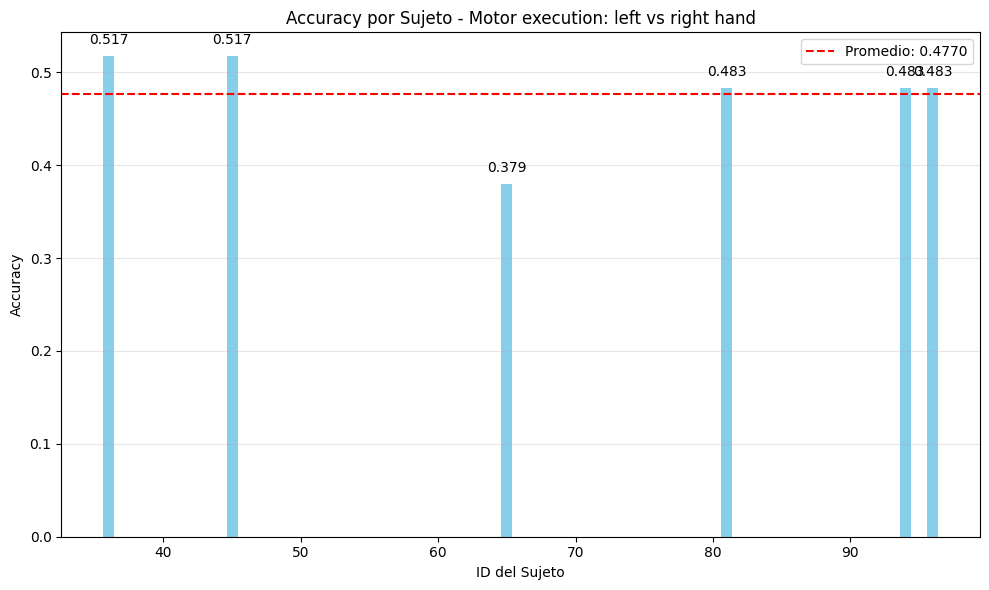

In [8]:
from predict_with_same_experiment import predict_with_same_experiment

import os
import glob

# Encontrar el modelo .joblib más reciente
model_files = glob.glob('../models/*.joblib')
if model_files:
    model_files.sort(key=lambda x: os.path.getmtime(x), reverse=True)
    latest_model = model_files[0]
    print(f"Usando el modelo más reciente: {latest_model}")
    
    # Ahora puedes pasar este modelo específico
    prediction_results = predict_with_same_experiment(num_subjects=6, model_path=latest_model)
else:
    print("No se encontraron modelos .joblib en el directorio ../models/")
